# Project V1.5 Final Report

이 노트북은 `Next200 v1.5`의 최종 정리본입니다.

핵심 목적은 세 가지입니다.

1. `v1`에서 무엇을 개선했는지 요약
2. 어떤 모델과 피처 조합이 가장 좋았는지 정리
3. `v1`과 `v1.5_best`를 직접 비교


## Summary

- `v1` 기준 모델: `LightGBM + core 10개 피처`
- `v1.5_best` 기준 모델: `XGBoost + 11개 피처`
- holdout(`2025_H1`, `2025_H2`) 기준 `strong_in/out precision`과 `top200_accuracy` 모두 개선
- 특히 `strong_out_precision` 개선 폭이 가장 큼


## 22. 실제 모델 비교를 위한 Historical Snapshot 재구성

다행히 SQL dump 안에 아래 테이블이 있어서,
과거 반기(`2020_H2 ~ 2025_H2`) 기준으로 학습용 snapshot을 노트북 안에서 재구성할 수 있습니다.

- `feature_krx`
- `major_holder`
- `foreign_holding`
- `labels`
- `stock_meta`
- `sector_map`
- `period`

즉 이제부터는 `v1.5`에서 실제 모델별/피처별 비교까지 가능한 단계로 들어갑니다.


In [1]:
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from src.sql_dump import load_table

try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
except Exception:
    CATBOOST_AVAILABLE = False

pd.set_option("display.max_rows", 200)


NameError: name 'pd' is not defined

In [ ]:
def historical_period_sort_key(period_value: str) -> tuple[int, int]:
    year_text, half_text = str(period_value).split("_")
    half_rank = 1 if half_text == "H1" else 2
    return int(year_text), half_rank



In [ ]:
sql_path = BASE_DIR / "data" / "raw" / "kospi_db_full_20260320.sql"

feature_krx_hist = load_table(sql_path, "feature_krx")
labels_hist = load_table(sql_path, "labels")
major_holder_hist = load_table(sql_path, "major_holder")
foreign_holding_hist = load_table(sql_path, "foreign_holding")
stock_meta_hist = load_table(sql_path, "stock_meta")
sector_map_hist = load_table(sql_path, "sector_map")
period_hist = load_table(sql_path, "period")

for frame in [feature_krx_hist, labels_hist, major_holder_hist, foreign_holding_hist, stock_meta_hist]:
    if "ticker" in frame.columns:
        frame["ticker"] = frame["ticker"].astype(str).str.zfill(6)

feature_krx_hist["period"] = feature_krx_hist["period"].astype(str)
labels_hist["period"] = labels_hist["period"].astype(str)
major_holder_hist["period"] = major_holder_hist["period"].astype(str)

period_hist["period"] = period_hist["period"].astype(str)
historical_period_order = sorted(period_hist["period"].tolist(), key=historical_period_sort_key)
prev_period_map = {
    period: (historical_period_order[idx - 1] if idx > 0 else None)
    for idx, period in enumerate(historical_period_order)
}

print("historical periods:", historical_period_order)
print("catboost_available:", CATBOOST_AVAILABLE)


historical periods: ['2020_H1', '2020_H2', '2021_H1', '2021_H2', '2022_H1', '2022_H2', '2023_H1', '2023_H2', '2024_H1', '2024_H2', '2025_H1', '2025_H2', '2026_H1']
catboost_available: False


In [ ]:
def build_historical_foreign_features(
    foreign_holding: pd.DataFrame,
    period_frame: pd.DataFrame,
    ordered_periods: list[str],
    prev_map: dict[str, str | None],
) -> pd.DataFrame:
    foreign = foreign_holding.copy()
    foreign["ticker"] = foreign["ticker"].astype(str).str.zfill(6)
    foreign["obs_date"] = pd.to_datetime(
        pd.to_numeric(foreign["ym"], errors="coerce").astype("Int64").astype(str) + "01",
        format="%Y%m%d",
        errors="coerce",
    )
    foreign["foreign_holding_ratio"] = pd.to_numeric(foreign["foreign_holding_ratio"], errors="coerce")
    foreign["foreign_limit_exhaustion_rate"] = pd.to_numeric(
        foreign["foreign_limit_exhaustion_rate"], errors="coerce"
    )

    lookup = period_frame.set_index("period")
    rows = []
    for period in ordered_periods:
        current = lookup.loc[period]
        current_start = pd.to_datetime(current["period_start"], errors="coerce")
        current_end = pd.to_datetime(current["period_end"], errors="coerce")
        current_slice = foreign[
            (foreign["obs_date"] >= current_start) & (foreign["obs_date"] <= current_end)
        ].sort_values(["ticker", "obs_date"])

        current_agg = (
            current_slice.groupby("ticker")
            .agg(
                avg_foreign_ratio=("foreign_holding_ratio", "mean"),
                last_foreign_ratio=("foreign_holding_ratio", "last"),
                avg_exhaustion_rate=("foreign_limit_exhaustion_rate", "mean"),
            )
            .reset_index()
        )

        prev_period = prev_map.get(period)
        if prev_period is not None:
            prev_row = lookup.loc[prev_period]
            prev_start = pd.to_datetime(prev_row["period_start"], errors="coerce")
            prev_end = pd.to_datetime(prev_row["period_end"], errors="coerce")
            prev_slice = foreign[
                (foreign["obs_date"] >= prev_start) & (foreign["obs_date"] <= prev_end)
            ]
            prev_agg = (
                prev_slice.groupby("ticker")
                .agg(prev_avg_foreign_ratio=("foreign_holding_ratio", "mean"))
                .reset_index()
            )
            current_agg = current_agg.merge(prev_agg, on="ticker", how="left")
        else:
            current_agg["prev_avg_foreign_ratio"] = np.nan

        current_agg["foreign_change"] = (
            current_agg["avg_foreign_ratio"] - current_agg["prev_avg_foreign_ratio"].fillna(0.0)
        )
        current_agg["period"] = period
        rows.append(
            current_agg[
                ["period", "ticker", "avg_foreign_ratio", "last_foreign_ratio", "avg_exhaustion_rate", "foreign_change"]
            ]
        )

    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


def build_historical_snapshot() -> pd.DataFrame:
    foreign_features = build_historical_foreign_features(
        foreign_holding_hist,
        period_hist,
        historical_period_order,
        prev_period_map,
    )

    snapshot = feature_krx_hist.merge(
        major_holder_hist[
            ["period", "ticker", "major_holder_ratio", "treasury_ratio", "non_float_ratio", "float_rate"]
        ],
        on=["period", "ticker"],
        how="left",
    )
    snapshot = snapshot.merge(
        labels_hist[["period", "ticker", "was_member", "label_in", "label_out", "actual_rank", "is_member"]],
        on=["period", "ticker"],
        how="left",
    )
    snapshot = snapshot.merge(
        stock_meta_hist[["ticker", "list_date", "is_not_common", "is_reits", "ksic_sector"]],
        on="ticker",
        how="left",
    )
    snapshot = snapshot.merge(
        sector_map_hist[["ksic_sector", "gics_sector_2023", "gics_sector_pre2023", "krx_group"]],
        on="ksic_sector",
        how="left",
        suffixes=("", "_map"),
    )
    snapshot = snapshot.merge(foreign_features, on=["period", "ticker"], how="left")

    snapshot["gics_sector"] = (
        snapshot["gics_sector"]
        .fillna(snapshot["gics_sector_2023"])
        .fillna(snapshot["gics_sector_pre2023"])
        .fillna("기타")
    )
    snapshot["krx_group"] = snapshot["krx_group"].fillna(snapshot.get("krx_group_map")).fillna("기타")

    prev_rank_frame = feature_krx_hist[["period", "ticker", "period_rank"]].rename(
        columns={"period": "prev_period", "period_rank": "prev_rank"}
    )
    snapshot["prev_period"] = snapshot["period"].map(prev_period_map)
    snapshot = snapshot.merge(prev_rank_frame, on=["prev_period", "ticker"], how="left")

    prev_member_frame = labels_hist[["period", "ticker", "is_member"]].rename(
        columns={"period": "prev_period", "is_member": "prev_was_member"}
    )
    snapshot = snapshot.merge(prev_member_frame, on=["prev_period", "ticker"], how="left")
    snapshot["prev_was_member"] = snapshot["prev_was_member"].fillna(snapshot["was_member"]).fillna(0)

    snapshot["float_mktcap"] = snapshot["avg_mktcap"] * snapshot["float_rate"].fillna(0.0)
    snapshot["float_mktcap_rank"] = snapshot.groupby("period")["float_mktcap"].rank(
        ascending=False, method="first"
    )
    snapshot["dist_from_200"] = snapshot["period_rank"] - 200
    snapshot["float_dist_from_200"] = snapshot["float_mktcap_rank"] - 200
    snapshot["rank_change"] = snapshot["prev_rank"].fillna(0.0) - snapshot["period_rank"]

    sector_count = snapshot.groupby(["period", "gics_sector"])["ticker"].transform("count")
    snapshot["sector_rank"] = snapshot.groupby(["period", "gics_sector"])["period_rank"].rank(
        method="first"
    )
    snapshot["sector_relative_rank"] = snapshot["sector_rank"] / sector_count

    sector_in_rate = snapshot.groupby("gics_sector")["label_in"].mean().to_dict()
    snapshot["sector_member_score"] = snapshot["gics_sector"].map(sector_in_rate).fillna(0.5)

    snapshot = snapshot[
        snapshot["is_not_common"].fillna(0).eq(0) & snapshot["is_reits"].fillna(0).eq(0)
    ].copy()

    period_lookup = period_hist.set_index("period")
    snapshot["period_end"] = pd.to_datetime(snapshot["period"].map(period_lookup["period_end"]), errors="coerce")
    listing_date = pd.to_datetime(snapshot["list_date"], errors="coerce")
    listing_months = (
        (snapshot["period_end"].dt.year - listing_date.dt.year) * 12
        + (snapshot["period_end"].dt.month - listing_date.dt.month)
    )
    snapshot = snapshot[~((listing_months < 6) & listing_months.notna())].copy()

    numeric_columns = [
        "period_rank",
        "turnover_ratio",
        "avg_mktcap",
        "float_rate",
        "major_holder_ratio",
        "treasury_ratio",
        "non_float_ratio",
        "avg_foreign_ratio",
        "last_foreign_ratio",
        "avg_exhaustion_rate",
        "foreign_change",
        "prev_rank",
        "prev_was_member",
        "float_mktcap",
        "float_mktcap_rank",
        "dist_from_200",
        "float_dist_from_200",
        "rank_change",
        "sector_rank",
        "sector_relative_rank",
        "sector_member_score",
        "label_in",
        "label_out",
        "is_member",
    ]
    for column in numeric_columns:
        if column in snapshot.columns:
            snapshot[column] = pd.to_numeric(snapshot[column], errors="coerce").fillna(0.0)

    return snapshot


historical_snapshot_df = build_historical_snapshot()
historical_snapshot_df.head()


,period,ticker,avg_mktcap,float_ratio,gics_sector,krx_group,period_rank,turnover_ratio,major_holder_ratio,treasury_ratio,non_float_ratio,float_rate,was_member,label_in,label_out,actual_rank,is_member,list_date,is_not_common,is_reits,ksic_sector,gics_sector_2023,gics_sector_pre2023,krx_group_map,avg_foreign_ratio,last_foreign_ratio,avg_exhaustion_rate,foreign_change,prev_period,prev_rank,prev_was_member,float_mktcap,float_mktcap_rank,dist_from_200,float_dist_from_200,rank_change,sector_rank,sector_relative_rank,sector_member_score,period_end
1,2020_H1,000100,2949761600000,0.6001,헬스케어,제약,77,0.141180,0.1560,0.0878,0.2438,0.7562,1.0,0.0,0.0,55.0,1.0,1962-11-01,0,0,제약,헬스케어,헬스케어,제약,21.934167,20.19,21.934167,21.934167,None,0.0,1.0,2.230610e+12,60.0,-123,-140.0,-77.0,4.0,0.181818,0.025974,2020-04-30
2,2020_H1,010050,438205320000,0.0000,금융 및 부동산,금융 및 부동산,263,0.060158,0.5984,0.0001,0.5985,0.4015,NaN,0.0,0.0,NaN,0.0,NaT,0,0,기타금융,금융 및 부동산,금융 및 부동산,금융 및 부동산,1.971667,1.95,1.971667,1.971667,None,0.0,0.0,1.759394e+11,258.0,63,58.0,-263.0,53.0,0.883333,0.025641,2020-04-30
3,2020_H1,010060,1585983280000,0.5538,소재,화학,118,0.191236,0.2231,0.0000,0.2231,0.7769,1.0,0.0,0.0,154.0,1.0,1985-07-09,0,0,화학,소재,소재,화학,24.101667,23.64,24.101667,24.101667,None,0.0,1.0,1.232150e+12,88.0,-82,-112.0,-118.0,20.0,0.333333,0.039252,2020-04-30
4,2020_H1,010120,1403820000000,0.0125,정보기술,전기·전자,130,0.067942,0.4825,0.0225,0.5050,0.4950,1.0,0.0,0.0,121.0,1.0,1994-07-11,0,0,전기·전자,정보기술,정보기술,전기·전자,17.743333,18.53,17.743333,17.743333,None,0.0,1.0,6.948909e+11,129.0,-70,-71.0,-130.0,10.0,0.416667,0.055838,2020-04-30
5,2020_H1,010130,8023148600000,0.0000,소재,금속,35,0.062841,0.4839,0.0634,0.5473,0.4527,1.0,0.0,0.0,33.0,1.0,1990-07-28,0,0,금속,소재,소재,금속,25.680000,23.29,25.680000,25.680000,None,0.0,1.0,3.632079e+12,37.0,-165,-163.0,-35.0,7.0,0.116667,0.039252,2020-04-30


In [ ]:
historical_snapshot_summary_df = pd.DataFrame(
    {
        "metric": [
            "rows",
            "period_count",
            "ticker_count",
            "train_rows",
            "test_rows",
        ],
        "value": [
            len(historical_snapshot_df),
            historical_snapshot_df["period"].nunique(),
            historical_snapshot_df["ticker"].nunique(),
            historical_snapshot_df["period"].isin(pkg.get("train_periods", [])).sum(),
            historical_snapshot_df["period"].isin(pkg.get("test_periods", [])).sum(),
        ],
    }
)
historical_snapshot_summary_df


,metric,value
0,rows,3398
1,period_count,12
2,ticker_count,411
3,train_rows,2544
4,test_rows,566


## 23. v1.5 실험용 feature pool 확정

In [ ]:
v1_core_features = list(pkg.get("features", []))

v1_5_candidate_features = [
    "prev_was_member",
    "avg_foreign_ratio",
    "last_foreign_ratio",
    "avg_exhaustion_rate",
    "avg_mktcap",
    "float_rate",
    "dist_from_200",
    "float_dist_from_200",
    "float_mktcap_rank",
    "rank_change",
    "non_float_ratio",
]

experiment_feature_pool = [feature for feature in v1_core_features + v1_5_candidate_features if feature in historical_snapshot_df.columns]

feature_pool_df = pd.DataFrame(
    {
        "feature": experiment_feature_pool,
        "source": ["core" if feature in v1_core_features else "candidate" for feature in experiment_feature_pool],
    }
)
feature_pool_df


,feature,source
0,period_rank,core
1,treasury_ratio,core
2,sector_relative_rank,core
3,prev_rank,core
4,major_holder_ratio,core
5,sector_rank,core
6,foreign_change,core
7,turnover_ratio,core
8,sector_member_score,core
9,float_mktcap,core


## 24. 중요도 2개 방식으로 feature 순위 매기기

여기서는 `LightGBM gain importance`와 `permutation importance`를 같이 보고,
두 순위의 평균으로 `combined_rank`를 만듭니다.

이 순위를 기준으로 `top 5 / 10 / 15 / 20 / 25` feature 실험을 진행합니다.


In [ ]:
train_periods = list(pkg.get("train_periods", []))
test_periods = list(pkg.get("test_periods", []))

train_snapshot_df = historical_snapshot_df[historical_snapshot_df["period"].isin(train_periods)].copy()
test_snapshot_df = historical_snapshot_df[historical_snapshot_df["period"].isin(test_periods)].copy()

X_train_full = train_snapshot_df[experiment_feature_pool].fillna(0.0)
y_train_full = train_snapshot_df["is_member"].fillna(0).astype(int)

importance_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    class_weight="balanced",
    verbosity=-1,
)
importance_model.fit(X_train_full, y_train_full)

gain_importance = pd.Series(importance_model.feature_importances_, index=experiment_feature_pool)
perm_result = permutation_importance(
    importance_model,
    X_train_full,
    y_train_full,
    n_repeats=5,
    random_state=42,
    scoring="roc_auc",
)
perm_importance = pd.Series(perm_result.importances_mean, index=experiment_feature_pool)

feature_rank_df = pd.DataFrame(
    {
        "gain_importance": gain_importance,
        "gain_rank": gain_importance.rank(ascending=False, method="min"),
        "perm_importance": perm_importance,
        "perm_rank": perm_importance.rank(ascending=False, method="min"),
        "source": ["core" if feature in v1_core_features else "candidate" for feature in experiment_feature_pool],
    }
)
feature_rank_df["combined_rank"] = feature_rank_df[["gain_rank", "perm_rank"]].mean(axis=1)
feature_rank_df = feature_rank_df.sort_values(["combined_rank", "gain_rank", "perm_rank"]).reset_index()
feature_rank_df.rename(columns={"index": "feature"}, inplace=True)
feature_rank_df


,feature,gain_importance,gain_rank,perm_importance,perm_rank,source,combined_rank
0,period_rank,798,1.0,6.400453e-03,2.0,core,1.5
1,foreign_change,652,3.0,1.028705e-06,7.0,core,5.0
2,sector_rank,588,4.0,1.763493e-06,6.0,core,5.0
3,major_holder_ratio,557,6.0,5.878312e-06,4.0,core,5.0
4,sector_relative_rank,544,7.0,9.258341e-05,3.0,core,5.0
5,rank_change,677,2.0,1.469578e-07,11.0,candidate,6.5
6,treasury_ratio,523,8.0,3.526987e-06,5.0,core,6.5
7,turnover_ratio,558,5.0,2.939156e-07,10.0,core,7.5
8,prev_was_member,340,15.0,1.311697e-01,1.0,candidate,8.0
9,avg_mktcap,460,10.0,5.878312e-07,8.0,candidate,9.0


## 27. 피처 개수별 coarse search

In [ ]:
ranked_feature_list = feature_rank_df["feature"].tolist()

coarse_feature_counts = [count for count in [5, 10, 15, 20, 25] if count <= len(ranked_feature_list)]
coarse_feature_counts


[5, 10, 15, 20]

In [ ]:
coarse_result_frames = []

for feature_count in coarse_feature_counts:
    selected_features = ranked_feature_list[:feature_count]
    for model_name, model in model_candidates.items():
        result_df = fit_and_score_model(
            model_name=model_name,
            model=model,
            feature_list=selected_features,
            train_df=train_snapshot_df,
            test_df=test_snapshot_df,
            periods=test_periods,
        )
        coarse_result_frames.append(result_df)

coarse_model_results_df = pd.concat(coarse_result_frames, ignore_index=True)
coarse_model_results_df["precision_priority_score"] = (
    coarse_model_results_df["strong_in_precision"] + coarse_model_results_df["strong_out_precision"]
) / 2.0

coarse_model_results_df


,top200_accuracy,strong_in_precision,strong_out_precision,actual_member_avg_pred_rank,actual_in_avg_pred_rank,actual_out_avg_pred_rank,top100_member_precision,top200_member_precision,period,model,feature_count,feature_list,precision_priority_score
0,0.890,0.150000,0.000000,107.450000,210.444444,177.285714,1.00,0.890,2025_H1,LightGBM,5,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank",0.075000
1,0.890,0.250000,0.000000,107.616162,163.714286,187.000000,0.97,0.890,2025_H2,LightGBM,5,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank",0.125000
2,0.890,0.105263,0.000000,107.250000,214.333333,191.285714,1.00,0.890,2025_H1,XGBoost,5,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank",0.052632
3,0.885,0.250000,0.000000,107.828283,163.714286,185.833333,0.97,0.885,2025_H2,XGBoost,5,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank",0.125000
4,0.890,0.055556,0.000000,107.770000,215.777778,188.571429,1.00,0.890,2025_H1,RandomForest,5,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank",0.027778
5,0.870,0.200000,0.000000,107.959596,161.571429,183.000000,0.98,0.870,2025_H2,RandomForest,5,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank",0.100000
6,0.890,0.055556,0.000000,108.005000,215.000000,192.571429,1.00,0.890,2025_H1,ExtraTrees,5,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank",0.027778
7,0.870,0.200000,0.000000,108.252525,164.714286,188.000000,0.98,0.870,2025_H2,ExtraTrees,5,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank",0.100000
8,0.870,0.150000,0.000000,110.735000,201.666667,205.000000,0.98,0.870,2025_H1,LogisticRegression,5,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank",0.075000
9,0.850,0.250000,0.000000,110.025253,134.714286,193.333333,0.98,0.850,2025_H2,LogisticRegression,5,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank",0.125000


In [ ]:
coarse_model_summary_df = (
    coarse_model_results_df.groupby(["model", "feature_count"])[
        [
            "precision_priority_score",
            "strong_in_precision",
            "strong_out_precision",
            "top200_accuracy",
            "top100_member_precision",
            "top200_member_precision",
            "actual_member_avg_pred_rank",
            "actual_in_avg_pred_rank",
            "actual_out_avg_pred_rank",
        ]
    ]
    .mean()
    .reset_index()
    .sort_values(
        [
            "precision_priority_score",
            "top200_accuracy",
            "top100_member_precision",
            "actual_member_avg_pred_rank",
        ],
        ascending=[False, False, False, True],
    )
)
coarse_model_summary_df


,model,feature_count,precision_priority_score,strong_in_precision,strong_out_precision,top200_accuracy,top100_member_precision,top200_member_precision,actual_member_avg_pred_rank,actual_in_avg_pred_rank,actual_out_avg_pred_rank
17,XGBoost,10,0.521429,0.342857,0.700000,0.9500,0.985,0.9500,103.354495,219.761905,148.357143
3,ExtraTrees,20,0.483333,0.383333,0.583333,0.9575,0.990,0.9575,102.567677,224.793651,159.535714
7,LightGBM,20,0.476623,0.253247,0.700000,0.9450,0.980,0.9450,103.656742,225.571429,147.916667
2,ExtraTrees,15,0.450000,0.483333,0.416667,0.9575,0.990,0.9575,102.635808,222.619048,155.440476
18,XGBoost,15,0.432540,0.365079,0.500000,0.9525,0.985,0.9525,103.340152,219.992063,143.321429
14,RandomForest,15,0.427381,0.321429,0.533333,0.9525,0.995,0.9525,102.707500,221.619048,160.595238
13,RandomForest,10,0.416964,0.383929,0.450000,0.9550,0.990,0.9550,102.880530,219.301587,154.333333
5,LightGBM,10,0.396825,0.293651,0.500000,0.9500,0.980,0.9500,103.331061,220.595238,156.190476
1,ExtraTrees,10,0.385714,0.321429,0.450000,0.9525,0.985,0.9525,102.871136,222.301587,151.428571
15,RandomForest,20,0.379464,0.383929,0.375000,0.9550,0.990,0.9550,102.894015,221.579365,157.535714


## 30. XGBoost 집중 탐색: 5개~15개 피처

여기서는 `XGBoost`만 따로 떼서 `5~15개` 피처를 모두 비교합니다.

목표는 아래 두 가지입니다.

- `몇 개 피처`일 때 성능이 가장 좋은지 확인
- 그때 `실제로 선택된 피처 목록`이 무엇인지 확인


In [ ]:
focused_model_candidates = {
    model_name: model_candidates[model_name]
    for model_name in ["XGBoost", "LightGBM", "ExtraTrees"]
    if model_name in model_candidates
}

focused_model_candidates.keys()


dict_keys(['XGBoost', 'LightGBM', 'ExtraTrees'])

In [ ]:
xgb_feature_count_range = list(range(5, min(15, len(ranked_feature_list)) + 1))
xgb_feature_count_range


[5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

In [ ]:
xgb_fine_frames = []

for feature_count in xgb_feature_count_range:
    selected_features = ranked_feature_list[:feature_count]
    result_df = fit_and_score_model(
        model_name="XGBoost",
        model=model_candidates["XGBoost"],
        feature_list=selected_features,
        train_df=train_snapshot_df,
        test_df=test_snapshot_df,
        periods=test_periods,
    )
    xgb_fine_frames.append(result_df)

xgb_fine_results_df = pd.concat(xgb_fine_frames, ignore_index=True)
xgb_fine_results_df["precision_priority_score"] = (
    xgb_fine_results_df["strong_in_precision"] + xgb_fine_results_df["strong_out_precision"]
) / 2.0

xgb_fine_results_df


,top200_accuracy,strong_in_precision,strong_out_precision,actual_member_avg_pred_rank,actual_in_avg_pred_rank,actual_out_avg_pred_rank,top100_member_precision,top200_member_precision,period,model,feature_count,feature_list,precision_priority_score
0,0.890,0.105263,0.000000,107.250000,214.333333,191.285714,1.00,0.890,2025_H1,XGBoost,5,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank",0.052632
1,0.885,0.250000,0.000000,107.828283,163.714286,185.833333,0.97,0.885,2025_H2,XGBoost,5,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank",0.125000
2,0.895,0.111111,0.000000,107.055000,222.222222,190.428571,0.99,0.895,2025_H1,XGBoost,6,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank, rank_change",0.055556
3,0.880,0.150000,0.000000,106.848485,167.285714,182.000000,0.98,0.880,2025_H2,XGBoost,6,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank, rank_change",0.075000
4,0.905,0.066667,0.000000,106.640000,224.111111,183.714286,1.00,0.905,2025_H1,XGBoost,7,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank, rank_change, treasury_ratio",0.033333
5,0.885,0.250000,0.100000,106.787879,168.142857,177.833333,0.98,0.885,2025_H2,XGBoost,7,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank, rank_change, treasury_ratio",0.175000
6,0.905,0.125000,0.000000,106.605000,223.555556,182.857143,0.99,0.905,2025_H1,XGBoost,8,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank, rank_change, treasury_ratio, turnover_ratio",0.062500
7,0.895,0.250000,0.000000,106.893939,174.714286,179.333333,0.98,0.895,2025_H2,XGBoost,8,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank, rank_change, treasury_ratio, turnover_ratio",0.125000
8,0.950,0.285714,1.000000,104.115000,229.333333,156.428571,0.99,0.950,2025_H1,XGBoost,9,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank, rank_change, treasury_ratio, turnover_ratio, prev_was_member",0.642857
9,0.950,0.400000,0.333333,102.616162,210.142857,141.333333,0.98,0.950,2025_H2,XGBoost,9,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank, rank_change, treasury_ratio, turnover_ratio, prev_was_member",0.366667


In [ ]:
xgb_fine_summary_df = (
    xgb_fine_results_df.groupby("feature_count")[
        [
            "precision_priority_score",
            "strong_in_precision",
            "strong_out_precision",
            "top200_accuracy",
            "top100_member_precision",
            "top200_member_precision",
            "actual_member_avg_pred_rank",
            "actual_in_avg_pred_rank",
            "actual_out_avg_pred_rank",
        ]
    ]
    .mean()
    .reset_index()
    .sort_values(
        [
            "precision_priority_score",
            "top200_accuracy",
            "top100_member_precision",
            "actual_member_avg_pred_rank",
        ],
        ascending=[False, False, False, True],
    )
)
xgb_fine_summary_df


,feature_count,precision_priority_score,strong_in_precision,strong_out_precision,top200_accuracy,top100_member_precision,top200_member_precision,actual_member_avg_pred_rank,actual_in_avg_pred_rank,actual_out_avg_pred_rank
6,11,0.588095,0.342857,0.833333,0.9500,0.980,0.9500,103.678687,220.261905,141.238095
5,10,0.521429,0.342857,0.700000,0.9500,0.985,0.9500,103.354495,219.761905,148.357143
8,13,0.510714,0.271429,0.750000,0.9475,0.985,0.9475,103.505253,222.111111,148.011905
4,9,0.504762,0.342857,0.666667,0.9500,0.985,0.9500,103.365581,219.738095,148.880952
7,12,0.476623,0.253247,0.700000,0.9450,0.985,0.9450,103.550682,220.706349,145.440476
10,15,0.432540,0.365079,0.500000,0.9525,0.985,0.9525,103.340152,219.992063,143.321429
9,14,0.219048,0.271429,0.166667,0.9475,0.985,0.9475,103.522172,221.436508,146.250000
2,7,0.104167,0.158333,0.050000,0.8950,0.990,0.8950,106.713939,196.126984,180.773810
3,8,0.093750,0.187500,0.000000,0.9000,0.985,0.9000,106.749470,199.134921,181.095238
0,5,0.088816,0.177632,0.000000,0.8875,0.985,0.8875,107.539141,189.023810,188.559524


In [ ]:
xgb_best_feature_count = int(xgb_fine_summary_df.iloc[0]["feature_count"])
xgb_best_features = ranked_feature_list[:xgb_best_feature_count]

xgb_best_feature_df = pd.DataFrame(
    {
        "rank": list(range(1, len(xgb_best_features) + 1)),
        "feature": xgb_best_features,
        "source": [
            "core" if feature in v1_core_features else "candidate"
            for feature in xgb_best_features
        ],
    }
)

print("best_xgb_feature_count:", xgb_best_feature_count)
xgb_best_feature_df


best_xgb_feature_count: 11


,rank,feature,source
0,1,period_rank,core
1,2,foreign_change,core
2,3,sector_rank,core
3,4,major_holder_ratio,core
4,5,sector_relative_rank,core
5,6,rank_change,candidate
6,7,treasury_ratio,core
7,8,turnover_ratio,core
8,9,prev_was_member,candidate
9,10,avg_mktcap,candidate


## 31. 최종 3개 모델 집중 비교

여기서는 `XGBoost`, `LightGBM`, `ExtraTrees`만 놓고,
각 모델의 가장 유리한 피처 개수 구간을 비교합니다.

현재는 coarse search 결과를 기준으로 비교하지만,
필요하면 `LightGBM`, `ExtraTrees`도 이후에 `5~15` 세부 탐색으로 확장할 수 있습니다.


In [ ]:
focused_compare_df = coarse_model_summary_df[
    coarse_model_summary_df["model"].isin(["XGBoost", "LightGBM", "ExtraTrees"])
].copy()

focused_compare_df


,model,feature_count,precision_priority_score,strong_in_precision,strong_out_precision,top200_accuracy,top100_member_precision,top200_member_precision,actual_member_avg_pred_rank,actual_in_avg_pred_rank,actual_out_avg_pred_rank
17,XGBoost,10,0.521429,0.342857,0.700000,0.9500,0.985,0.9500,103.354495,219.761905,148.357143
3,ExtraTrees,20,0.483333,0.383333,0.583333,0.9575,0.990,0.9575,102.567677,224.793651,159.535714
7,LightGBM,20,0.476623,0.253247,0.700000,0.9450,0.980,0.9450,103.656742,225.571429,147.916667
2,ExtraTrees,15,0.450000,0.483333,0.416667,0.9575,0.990,0.9575,102.635808,222.619048,155.440476
18,XGBoost,15,0.432540,0.365079,0.500000,0.9525,0.985,0.9525,103.340152,219.992063,143.321429
5,LightGBM,10,0.396825,0.293651,0.500000,0.9500,0.980,0.9500,103.331061,220.595238,156.190476
1,ExtraTrees,10,0.385714,0.321429,0.450000,0.9525,0.985,0.9525,102.871136,222.301587,151.428571
19,XGBoost,20,0.334325,0.293651,0.375000,0.9500,0.975,0.9500,103.510631,221.341270,139.404762
6,LightGBM,15,0.330159,0.293651,0.366667,0.9500,0.990,0.9500,103.148258,224.833333,158.261905
4,LightGBM,5,0.100000,0.200000,0.000000,0.8900,0.985,0.8900,107.533081,187.079365,182.142857


In [ ]:
focused_best_by_model_df = (
    focused_compare_df.sort_values(
        [
            "precision_priority_score",
            "top200_accuracy",
            "top100_member_precision",
            "actual_member_avg_pred_rank",
        ],
        ascending=[False, False, False, True],
    )
    .groupby("model", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

focused_best_by_model_df


,model,feature_count,precision_priority_score,strong_in_precision,strong_out_precision,top200_accuracy,top100_member_precision,top200_member_precision,actual_member_avg_pred_rank,actual_in_avg_pred_rank,actual_out_avg_pred_rank
0,XGBoost,10,0.521429,0.342857,0.700000,0.9500,0.985,0.9500,103.354495,219.761905,148.357143
1,ExtraTrees,20,0.483333,0.383333,0.583333,0.9575,0.990,0.9575,102.567677,224.793651,159.535714
2,LightGBM,20,0.476623,0.253247,0.700000,0.9450,0.980,0.9450,103.656742,225.571429,147.916667


In [ ]:
focused_best_feature_map = {}
for _, row in focused_best_by_model_df.iterrows():
    model_name = row["model"]
    feature_count = int(row["feature_count"])
    focused_best_feature_map[model_name] = ranked_feature_list[:feature_count]

focused_best_feature_rows = []
for model_name, features in focused_best_feature_map.items():
    for rank, feature in enumerate(features, start=1):
        focused_best_feature_rows.append(
            {
                "model": model_name,
                "feature_count": len(features),
                "rank": rank,
                "feature": feature,
                "source": "core" if feature in v1_core_features else "candidate",
            }
        )

focused_best_feature_detail_df = pd.DataFrame(focused_best_feature_rows)
focused_best_feature_detail_df


,model,feature_count,rank,feature,source
0,XGBoost,10,1,period_rank,core
1,XGBoost,10,2,foreign_change,core
2,XGBoost,10,3,sector_rank,core
3,XGBoost,10,4,major_holder_ratio,core
4,XGBoost,10,5,sector_relative_rank,core
5,XGBoost,10,6,rank_change,candidate
6,XGBoost,10,7,treasury_ratio,core
7,XGBoost,10,8,turnover_ratio,core
8,XGBoost,10,9,prev_was_member,candidate
9,XGBoost,10,10,avg_mktcap,candidate


## 32. 현재 기준 최적 모델 요약

In [ ]:
focused_final_ranking_df = focused_best_by_model_df.sort_values(
    [
        "precision_priority_score",
        "top200_accuracy",
        "top100_member_precision",
        "actual_member_avg_pred_rank",
    ],
    ascending=[False, False, False, True],
).reset_index(drop=True)

focused_final_ranking_df


,model,feature_count,precision_priority_score,strong_in_precision,strong_out_precision,top200_accuracy,top100_member_precision,top200_member_precision,actual_member_avg_pred_rank,actual_in_avg_pred_rank,actual_out_avg_pred_rank
0,XGBoost,10,0.521429,0.342857,0.700000,0.9500,0.985,0.9500,103.354495,219.761905,148.357143
1,ExtraTrees,20,0.483333,0.383333,0.583333,0.9575,0.990,0.9575,102.567677,224.793651,159.535714
2,LightGBM,20,0.476623,0.253247,0.700000,0.9450,0.980,0.9450,103.656742,225.571429,147.916667


## 33. v1 vs v1.5 최종 후보 직접 비교

이제 현재 기준 최적 후보인 `v1.5 = XGBoost + 11개 피처`와
기존 `v1 = LightGBM + core 10개 피처`를 직접 비교합니다.

비교 우선순위는 동일합니다.

1. `strong_in_precision`, `strong_out_precision`
2. `top200_accuracy`
3. `rank 품질`


In [ ]:
v1_feature_list = list(pkg.get("features", []))

if "xgb_best_feature_count" not in globals():
    raise RuntimeError("먼저 XGBoost 집중 탐색 셀을 실행해서 xgb_best_feature_count를 만들어야 합니다.")

v1_5_best_feature_list = ranked_feature_list[:xgb_best_feature_count]

comparison_feature_sets_df = pd.DataFrame(
    [
        {
            "version": "v1",
            "model": "LightGBM",
            "feature_count": len(v1_feature_list),
            "feature_list": ", ".join(v1_feature_list),
        },
        {
            "version": "v1.5_best",
            "model": "XGBoost",
            "feature_count": len(v1_5_best_feature_list),
            "feature_list": ", ".join(v1_5_best_feature_list),
        },
    ]
)
comparison_feature_sets_df


,version,model,feature_count,feature_list
0,v1,LightGBM,10,"period_rank, treasury_ratio, sector_relative_rank, prev_rank, major_holder_ratio, sector_rank, foreign_change, turnover_ratio, sector_member_score, float_mktcap"
1,v1.5_best,XGBoost,11,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank, rank_change, treasury_ratio, turnover_ratio, prev_was_member, avg_mktcap, last_foreign_ratio"


In [ ]:
final_compare_frames = []

final_model_map = {
    "v1": (
        "LightGBM",
        LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            random_state=42,
            class_weight="balanced",
            verbosity=-1,
        ),
        v1_feature_list,
    ),
    "v1.5_best": (
        "XGBoost",
        XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42,
            eval_metric="logloss",
            n_jobs=1,
        ),
        v1_5_best_feature_list,
    ),
}

for version_name, (model_name, model, feature_list) in final_model_map.items():
    result_df = fit_and_score_model(
        model_name=model_name,
        model=model,
        feature_list=feature_list,
        train_df=train_snapshot_df,
        test_df=test_snapshot_df,
        periods=test_periods,
    )
    result_df["version"] = version_name
    final_compare_frames.append(result_df)

v1_vs_v1_5_period_df = pd.concat(final_compare_frames, ignore_index=True)
v1_vs_v1_5_period_df["precision_priority_score"] = (
    v1_vs_v1_5_period_df["strong_in_precision"] + v1_vs_v1_5_period_df["strong_out_precision"]
) / 2.0

v1_vs_v1_5_period_df


,top200_accuracy,strong_in_precision,strong_out_precision,actual_member_avg_pred_rank,actual_in_avg_pred_rank,actual_out_avg_pred_rank,top100_member_precision,top200_member_precision,period,model,feature_count,feature_list,version,precision_priority_score
0,0.915,0.142857,0.000000,105.690000,223.888889,178.000000,0.99,0.915,2025_H1,LightGBM,10,"period_rank, treasury_ratio, sector_relative_rank, prev_rank, major_holder_ratio, sector_rank, foreign_change, turnover_ratio, sector_member_score, float_mktcap",v1,0.071429
1,0.900,0.200000,0.166667,106.070707,177.714286,181.666667,0.99,0.900,2025_H2,LightGBM,10,"period_rank, treasury_ratio, sector_relative_rank, prev_rank, major_holder_ratio, sector_rank, foreign_change, turnover_ratio, sector_member_score, float_mktcap",v1,0.183333
2,0.950,0.285714,1.000000,104.620000,230.666667,143.142857,0.98,0.950,2025_H1,XGBoost,11,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank, rank_change, treasury_ratio, turnover_ratio, prev_was_member, avg_mktcap, last_foreign_ratio",v1.5_best,0.642857
3,0.950,0.400000,0.666667,102.737374,209.857143,139.333333,0.98,0.950,2025_H2,XGBoost,11,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank, rank_change, treasury_ratio, turnover_ratio, prev_was_member, avg_mktcap, last_foreign_ratio",v1.5_best,0.533333


In [ ]:
v1_vs_v1_5_summary_df = (
    v1_vs_v1_5_period_df.groupby(["version", "model"])[
        [
            "precision_priority_score",
            "strong_in_precision",
            "strong_out_precision",
            "top200_accuracy",
            "top100_member_precision",
            "top200_member_precision",
            "actual_member_avg_pred_rank",
            "actual_in_avg_pred_rank",
            "actual_out_avg_pred_rank",
        ]
    ]
    .mean()
    .reset_index()
    .sort_values(
        [
            "precision_priority_score",
            "top200_accuracy",
            "top100_member_precision",
            "actual_member_avg_pred_rank",
        ],
        ascending=[False, False, False, True],
    )
)
v1_vs_v1_5_summary_df


,version,model,precision_priority_score,strong_in_precision,strong_out_precision,top200_accuracy,top100_member_precision,top200_member_precision,actual_member_avg_pred_rank,actual_in_avg_pred_rank,actual_out_avg_pred_rank
1,v1.5_best,XGBoost,0.588095,0.342857,0.833333,0.9500,0.98,0.9500,103.678687,220.261905,141.238095
0,v1,LightGBM,0.127381,0.171429,0.083333,0.9075,0.99,0.9075,105.880354,200.801587,179.833333


In [ ]:
v1_vs_v1_5_delta_df = v1_vs_v1_5_summary_df.set_index("version").copy()

if {"v1", "v1.5_best"}.issubset(v1_vs_v1_5_delta_df.index):
    delta_row = (
        v1_vs_v1_5_delta_df.loc["v1.5_best"][
            [
                "precision_priority_score",
                "strong_in_precision",
                "strong_out_precision",
                "top200_accuracy",
                "top100_member_precision",
                "top200_member_precision",
                "actual_member_avg_pred_rank",
                "actual_in_avg_pred_rank",
                "actual_out_avg_pred_rank",
            ]
        ]
        - v1_vs_v1_5_delta_df.loc["v1"][
            [
                "precision_priority_score",
                "strong_in_precision",
                "strong_out_precision",
                "top200_accuracy",
                "top100_member_precision",
                "top200_member_precision",
                "actual_member_avg_pred_rank",
                "actual_in_avg_pred_rank",
                "actual_out_avg_pred_rank",
            ]
        ]
    )
    v1_vs_v1_5_delta_view_df = delta_row.to_frame("v1.5_minus_v1").reset_index().rename(columns={"index": "metric"})
else:
    v1_vs_v1_5_delta_view_df = pd.DataFrame()

v1_vs_v1_5_delta_view_df


,metric,v1.5_minus_v1
0,precision_priority_score,0.460714
1,strong_in_precision,0.171429
2,strong_out_precision,0.75
3,top200_accuracy,0.0425
4,top100_member_precision,-0.01
5,top200_member_precision,0.0425
6,actual_member_avg_pred_rank,-2.201667
7,actual_in_avg_pred_rank,19.460317
8,actual_out_avg_pred_rank,-38.595238


## 34. v1 대비 v1.5 최종 해석 메모

In [ ]:
v1_vs_v1_5_note_df = pd.DataFrame(
    [
        {
            "question": "precision 기준으로 누가 우세한가?",
            "how_to_read": "precision_priority_score, strong_in_precision, strong_out_precision을 먼저 본다",
        },
        {
            "question": "top200 멤버 예측도 좋아졌는가?",
            "how_to_read": "top200_accuracy, top100/top200_member_precision을 본다",
        },
        {
            "question": "순위 품질은 어떤가?",
            "how_to_read": "actual_member_avg_pred_rank와 actual_out_avg_pred_rank가 낮을수록 좋다",
        },
        {
            "question": "최종 채택 기준은?",
            "how_to_read": "우선순위는 precision > top200_accuracy > rank 품질",
        },
    ]
)
v1_vs_v1_5_note_df


,question,how_to_read
0,precision 기준으로 누가 우세한가?,"precision_priority_score, strong_in_precision, strong_out_precision을 먼저 본다"
1,top200 멤버 예측도 좋아졌는가?,"top200_accuracy, top100/top200_member_precision을 본다"
2,순위 품질은 어떤가?,actual_member_avg_pred_rank와 actual_out_avg_pred_rank가 낮을수록 좋다
3,최종 채택 기준은?,우선순위는 precision > top200_accuracy > rank 품질


## 35. 2020_H1 ~ 2025_H2 전체 기간 시각 비교

여기서는 `v1`과 `v1.5_best`를 전체 기간에 대해 시각적으로 비교합니다.

주의:
- 이 비교는 `2025_H1`, `2025_H2` 테스트 구간뿐 아니라 과거 기간도 함께 포함합니다.
- 따라서 `train 구간 포함 전체 흐름 시각화`로 해석하는 것이 맞습니다.
- 최종 일반화 성능 판단은 여전히 `test period` 결과를 우선합니다.


In [ ]:
full_period_order = [period for period in historical_period_order if period != "2026_H1"]
full_period_order


['2020_H1',
 '2020_H2',
 '2021_H1',
 '2021_H2',
 '2022_H1',
 '2022_H2',
 '2023_H1',
 '2023_H2',
 '2024_H1',
 '2024_H2',
 '2025_H1',
 '2025_H2']

In [ ]:
def score_full_periods(version_name: str, model_name: str, model, feature_list: list[str]) -> pd.DataFrame:
    X_train = train_snapshot_df[feature_list].fillna(0.0)
    y_train = train_snapshot_df["is_member"].fillna(0).astype(int)
    model.fit(X_train, y_train)

    rows = []
    for period in full_period_order:
        period_frame = historical_snapshot_df[historical_snapshot_df["period"] == period].copy()
        if period_frame.empty:
            continue

        X_period = period_frame[feature_list].fillna(0.0)
        if hasattr(model, "predict_proba"):
            scores = model.predict_proba(X_period)[:, 1]
        else:
            scores = model.decision_function(X_period)

        period_frame["score"] = scores
        period_frame["pred_rank"] = period_frame["score"].rank(ascending=False, method="first")

        metric_row = evaluate_period_scores(period_frame)
        metric_row["period"] = period
        metric_row["version"] = version_name
        metric_row["model"] = model_name
        metric_row["feature_count"] = len(feature_list)
        rows.append(metric_row)

    return pd.DataFrame(rows)


In [ ]:
full_period_compare_frames = []

full_period_model_map = {
    "v1": (
        "LightGBM",
        LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            random_state=42,
            class_weight="balanced",
            verbosity=-1,
        ),
        v1_feature_list,
    ),
    "v1.5_best": (
        "XGBoost",
        XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42,
            eval_metric="logloss",
            n_jobs=1,
        ),
        v1_5_best_feature_list,
    ),
}

for version_name, (model_name, model, feature_list) in full_period_model_map.items():
    version_df = score_full_periods(version_name, model_name, model, feature_list)
    full_period_compare_frames.append(version_df)

full_period_compare_df = pd.concat(full_period_compare_frames, ignore_index=True)
full_period_compare_df["precision_priority_score"] = (
    full_period_compare_df["strong_in_precision"] + full_period_compare_df["strong_out_precision"]
) / 2.0

full_period_compare_df


,top200_accuracy,strong_in_precision,strong_out_precision,actual_member_avg_pred_rank,actual_in_avg_pred_rank,actual_out_avg_pred_rank,top100_member_precision,top200_member_precision,period,version,model,feature_count,precision_priority_score
0,0.900,0.300000,0.125000,106.505000,171.636364,248.142857,1.00,0.900,2020_H1,v1,LightGBM,10,0.212500
1,0.990,0.818182,1.000000,99.500000,156.777778,242.333333,1.00,0.990,2020_H2,v1,LightGBM,10,0.909091
2,0.980,0.571429,0.000000,98.500000,177.250000,229.500000,1.00,0.980,2021_H1,v1,LightGBM,10,0.285714
3,0.965,0.333333,1.000000,97.000000,148.000000,222.428571,1.00,0.965,2021_H2,v1,LightGBM,10,0.666667
4,0.985,0.875000,1.000000,99.000000,142.714286,222.500000,1.00,0.985,2022_H1,v1,LightGBM,10,0.937500
5,1.000,1.000000,0.000000,100.500000,195.000000,249.000000,1.00,1.000,2022_H2,v1,LightGBM,10,0.500000
6,1.000,1.000000,1.000000,100.500000,168.600000,215.400000,1.00,1.000,2023_H1,v1,LightGBM,10,1.000000
7,0.995,0.888889,1.000000,100.000000,162.250000,228.750000,1.00,0.995,2023_H2,v1,LightGBM,10,0.944444
8,0.985,0.833333,1.000000,99.000000,136.000000,215.857143,1.00,0.985,2024_H1,v1,LightGBM,10,0.916667
9,0.995,0.800000,1.000000,100.000000,163.750000,232.200000,1.00,0.995,2024_H2,v1,LightGBM,10,0.900000


In [ ]:
full_period_summary_df = (
    full_period_compare_df.groupby(["version", "model"])[
        [
            "precision_priority_score",
            "strong_in_precision",
            "strong_out_precision",
            "top200_accuracy",
            "top100_member_precision",
            "top200_member_precision",
            "actual_member_avg_pred_rank",
            "actual_in_avg_pred_rank",
            "actual_out_avg_pred_rank",
        ]
    ]
    .mean()
    .reset_index()
    .sort_values(
        [
            "precision_priority_score",
            "top200_accuracy",
            "top100_member_precision",
            "actual_member_avg_pred_rank",
        ],
        ascending=[False, False, False, True],
    )
)
full_period_summary_df


,version,model,precision_priority_score,strong_in_precision,strong_out_precision,top200_accuracy,top100_member_precision,top200_member_precision,actual_member_avg_pred_rank,actual_in_avg_pred_rank,actual_out_avg_pred_rank
1,v1.5_best,XGBoost,0.845112,0.759668,0.930556,0.978333,0.995833,0.978333,100.288531,199.248025,195.419444
0,v1,LightGBM,0.627279,0.646919,0.607639,0.967500,0.998333,0.967500,101.022142,168.631800,222.148214


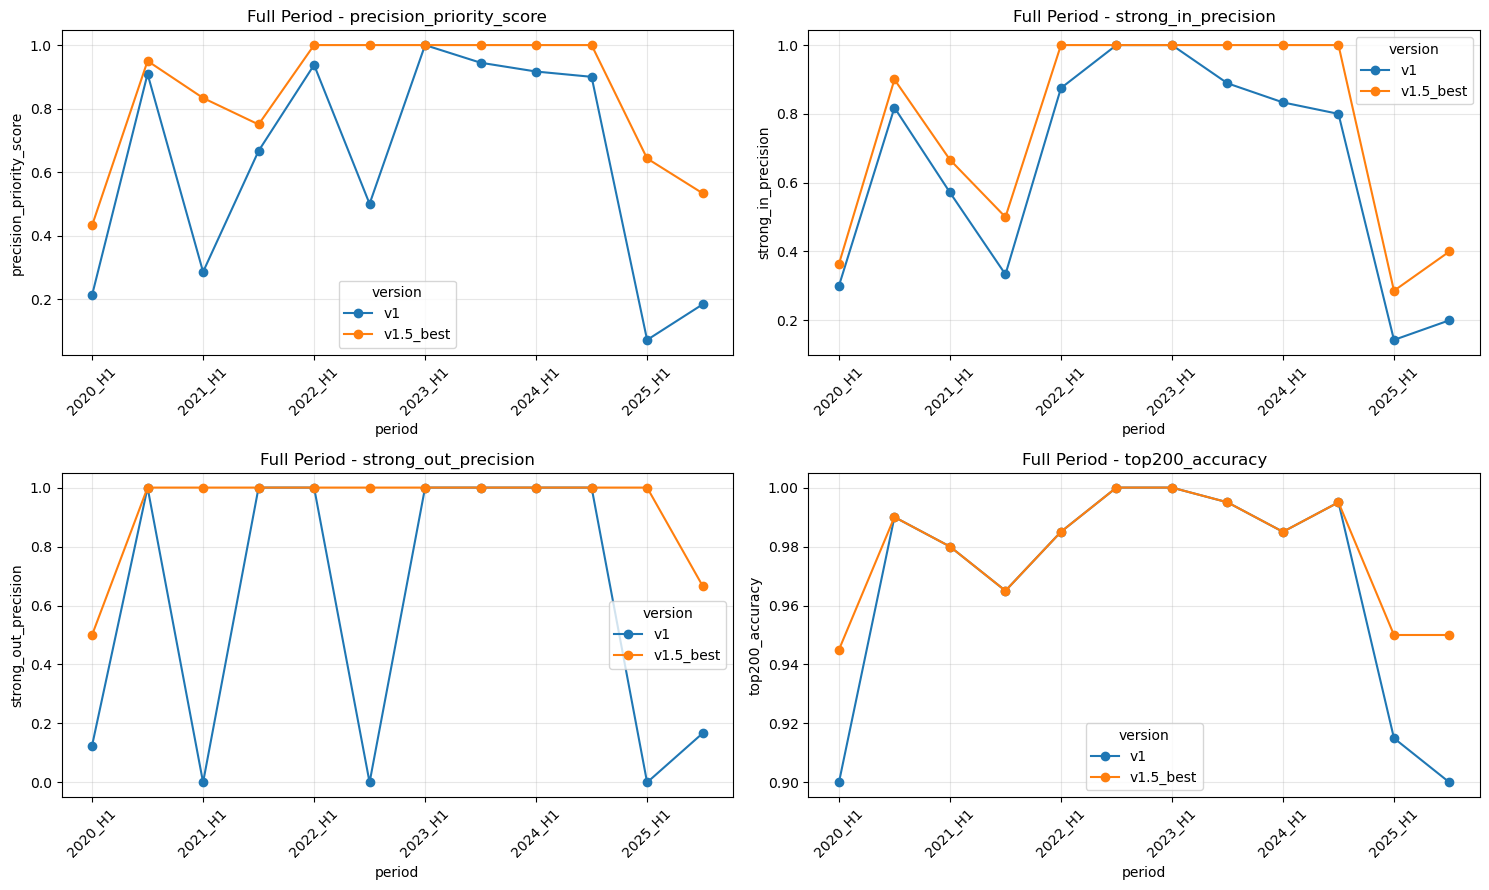

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.ravel()

for metric, ax in zip(
    ["precision_priority_score", "strong_in_precision", "strong_out_precision", "top200_accuracy"],
    axes,
):
    plot_df = full_period_compare_df.pivot(index="period", columns="version", values=metric)
    plot_df = plot_df.reindex(full_period_order)
    plot_df.plot(marker="o", ax=ax)
    ax.set_title(f"Full Period - {metric}")
    ax.grid(alpha=0.3)
    ax.set_xlabel("period")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


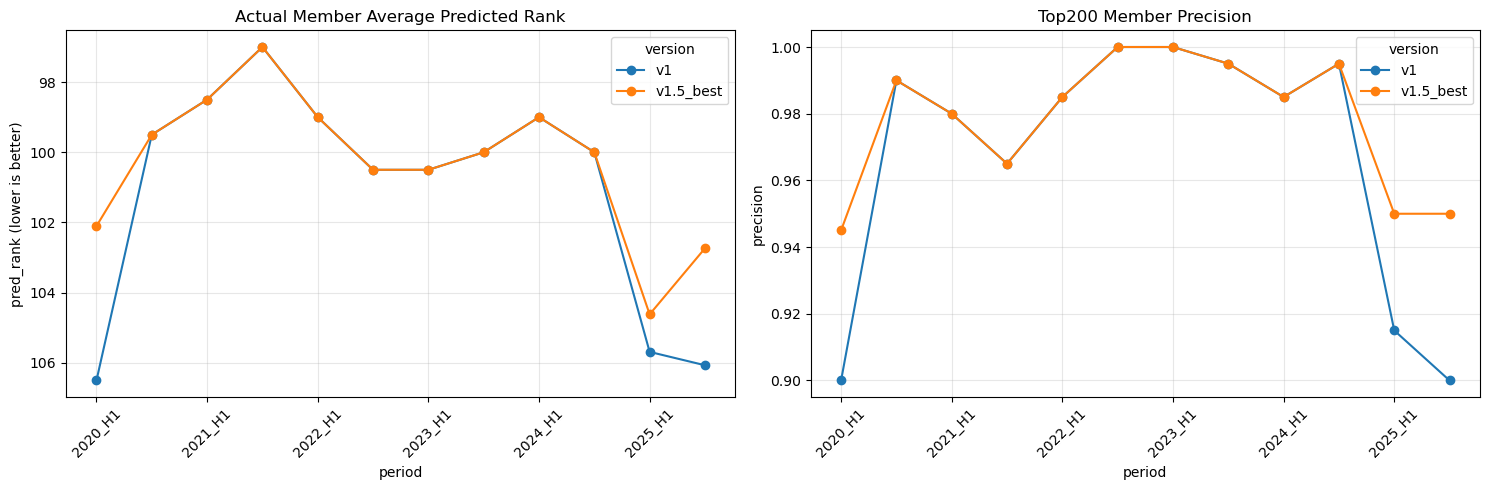

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

rank_plot_df = full_period_compare_df.pivot(index="period", columns="version", values="actual_member_avg_pred_rank")
rank_plot_df = rank_plot_df.reindex(full_period_order)
rank_plot_df.plot(marker="o", ax=axes[0])
axes[0].invert_yaxis()
axes[0].set_title("Actual Member Average Predicted Rank")
axes[0].set_ylabel("pred_rank (lower is better)")
axes[0].grid(alpha=0.3)
axes[0].tick_params(axis="x", rotation=45)

top200_plot_df = full_period_compare_df.pivot(index="period", columns="version", values="top200_member_precision")
top200_plot_df = top200_plot_df.reindex(full_period_order)
top200_plot_df.plot(marker="o", ax=axes[1])
axes[1].set_title("Top200 Member Precision")
axes[1].set_ylabel("precision")
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
train_test_tag_df = pd.DataFrame(
    {
        "period": full_period_order,
        "split_type": [
            "train" if period in train_periods else "test" if period in test_periods else "other"
            for period in full_period_order
        ],
    }
)
train_test_tag_df


,period,split_type
0,2020_H1,other
1,2020_H2,train
2,2021_H1,train
3,2021_H2,train
4,2022_H1,train
5,2022_H2,train
6,2023_H1,train
7,2023_H2,train
8,2024_H1,train
9,2024_H2,train


## 36. 지금까지 결과 기준 다음 할 일

현재 노트북 기준으로 다음 액션은 이렇게 정리할 수 있습니다.

1. `v1.5_best = XGBoost + 11개 피처`를 현재 최종 후보로 확정
2. `snapshot_version = v1_5_xgb_11` 같은 이름으로 SQL snapshot 관리 체계 반영
3. 필요하면 `XGBoost 10~12개` 주변 하이퍼파라미터까지 미세 조정
4. README는 발표용이 아니라 개인 포트폴리오 톤으로 재정리
